<a href="https://colab.research.google.com/github/PriSonoda/Challenge-Telecom-X/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd
from pandas import json_normalize

In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

In [3]:
response = requests.get(url)
data = response.json()

In [4]:
df = json_normalize(data)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [7]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [11]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [12]:
df.isnull().sum()
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [14]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [17]:
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(df['account.Charges.Total'].mean())

In [18]:
df['account.Charges.Total'].isnull().sum()

np.int64(0)

In [19]:
df = df.drop(columns=['customerID'])

In [20]:
categoricas = [
    'Churn', 'customer.gender', 'customer.Partner', 'customer.Dependents',
    'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
    'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport',
    'internet.StreamingTV', 'internet.StreamingMovies',
    'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod'
]

for col in categoricas:
    df[col] = df[col].astype('category')

In [21]:
df.dtypes

,0
Churn,category
customer.gender,category
customer.SeniorCitizen,int64
customer.Partner,category
customer.Dependents,category
customer.tenure,int64
phone.PhoneService,category
phone.MultipleLines,category
internet.InternetService,category
internet.OnlineSecurity,category


In [22]:
df['account.Contract'].unique()
df['internet.InternetService'].unique()
df['account.PaymentMethod'].unique()
df['Churn'].unique()

['No', 'Yes', '']
Categories (3, object): ['', 'No', 'Yes']

In [23]:
df['customer.tenure'].describe()
df['account.Charges.Monthly'].describe()
df['account.Charges.Total'].describe()

,account.Charges.Total
count,7267.000000
mean,2280.634213
std,2266.915104
min,18.800000
25%,401.400000
50%,1394.550000
75%,3778.525000
max,8684.800000


In [24]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2266.915104
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,401.400000
50%,0.000000,29.000000,70.300000,1394.550000
75%,0.000000,55.000000,89.875000,3778.525000
max,1.000000,72.000000,118.750000,8684.800000


In [25]:
df['Churn'].value_counts()
df['account.Contract'].value_counts()
df['internet.InternetService'].value_counts()

,count
internet.InternetService,
Fiber optic,3198
DSL,2488
No,1581


In [26]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2266.915104
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,401.400000
50%,0.000000,29.000000,70.300000,1394.550000
75%,0.000000,55.000000,89.875000,3778.525000
max,1.000000,72.000000,118.750000,8684.800000


In [27]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


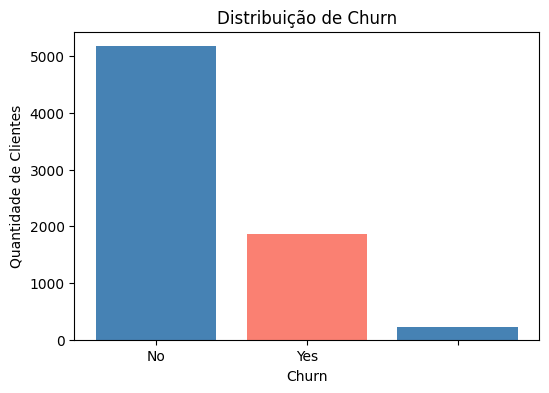

In [29]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index, churn_counts.values, color=['steelblue', 'salmon'])
plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [33]:
df.groupby('customer.gender')['Churn'].value_counts(normalize=True)

/tmp/ipykernel_281/3668084679.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer.gender')['Churn'].value_counts(normalize=True)


customer.gender  Churn
Female           No       0.709633
                 Yes      0.261414
                          0.028953
Male             No       0.714286
                 Yes      0.253061
                          0.032653
Name: proportion, dtype: float64

/tmp/ipykernel_281/1250080811.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prop = df.groupby('customer.gender')['Churn'].value_counts(normalize=True).rename('proporcao').reset_index()
/tmp/ipykernel_281/1250080811.py:4: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


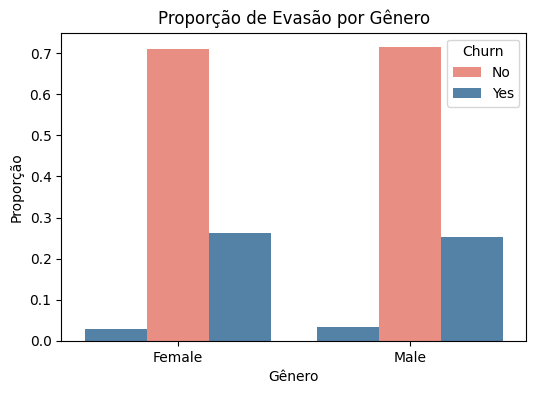

In [43]:
prop = df.groupby('customer.gender')['Churn'].value_counts(normalize=True).rename('proporcao').reset_index()

plt.figure(figsize=(6,4))
sns.barplot(
    data=prop,
    x='customer.gender',
    y='proporcao',
    hue='Churn',
    palette=['steelblue', 'salmon']  # mesmas cores do seu gráfico anterior
)

plt.title('Proporção de Evasão por Gênero')
plt.ylabel('Proporção')
plt.xlabel('Gênero')
plt.show()

In [34]:
df.groupby('account.Contract')['Churn'].value_counts(normalize=True)

/tmp/ipykernel_281/3137201874.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('account.Contract')['Churn'].value_counts(normalize=True)


account.Contract  Churn
Month-to-month    No       0.554307
                  Yes      0.413233
                           0.032459
One year          No       0.860434
                  Yes      0.109282
                           0.030283
Two year          No       0.944923
                           0.027539
                  Yes      0.027539
Name: proportion, dtype: float64

In [35]:
df.groupby('account.PaymentMethod')['Churn'].value_counts(normalize=True)

/tmp/ipykernel_281/3758812101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('account.PaymentMethod')['Churn'].value_counts(normalize=True)


account.PaymentMethod      Churn
Bank transfer (automatic)  No       0.809314
                           Yes      0.162366
                                    0.028320
Credit card (automatic)    No       0.822704
                           Yes      0.147959
                                    0.029337
Electronic check           No       0.529243
                           Yes      0.438037
                                    0.032720
Mailed check               No       0.783183
                           Yes      0.184985
                                    0.031832
Name: proportion, dtype: float64

In [36]:
df.groupby('internet.InternetService')['Churn'].value_counts(normalize=True)

/tmp/ipykernel_281/617707394.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('internet.InternetService')['Churn'].value_counts(normalize=True)


internet.InternetService  Churn
DSL                       No       0.788585
                          Yes      0.184486
                                   0.026929
Fiber optic               No       0.562539
                          Yes      0.405566
                                   0.031895
No                        No       0.893738
                          Yes      0.071474
                                   0.034788
Name: proportion, dtype: float64

In [37]:
df.groupby('internet.OnlineSecurity')['Churn'].value_counts(normalize=True)

/tmp/ipykernel_281/3627805991.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('internet.OnlineSecurity')['Churn'].value_counts(normalize=True)


internet.OnlineSecurity  Churn
No                       No       0.564579
                         Yes      0.404933
                                  0.030488
No internet service      No       0.893738
                         Yes      0.071474
                                  0.034788
Yes                      No       0.829644
                         Yes      0.141963
                                  0.028393
Name: proportion, dtype: float64

In [38]:
df.groupby('customer.SeniorCitizen')['Churn'].value_counts(normalize=True)

customer.SeniorCitizen  Churn
0                       No       0.740838
                        Yes      0.228924
                                 0.030238
1                       No       0.563452
                        Yes      0.402707
                                 0.033841
Name: proportion, dtype: float64

In [39]:
df.groupby('Churn')[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].mean()

/tmp/ipykernel_281/3582938727.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Churn')[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].mean()


,customer.tenure,account.Charges.Monthly,account.Charges.Total
Churn,,,
,31.571429,63.412277,2196.933705
No,37.569965,61.265124,2554.760104
Yes,17.979133,74.441332,1531.796094


In [40]:
df.groupby('Churn')[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].median()

/tmp/ipykernel_281/1124042345.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Churn')[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].median()


,customer.tenure,account.Charges.Monthly,account.Charges.Total
Churn,,,
,29.0,69.100,1163.175
No,38.0,64.425,1689.175
Yes,10.0,79.650,703.550


/tmp/ipykernel_281/2963091223.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,
/tmp/ipykernel_281/2963091223.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df,


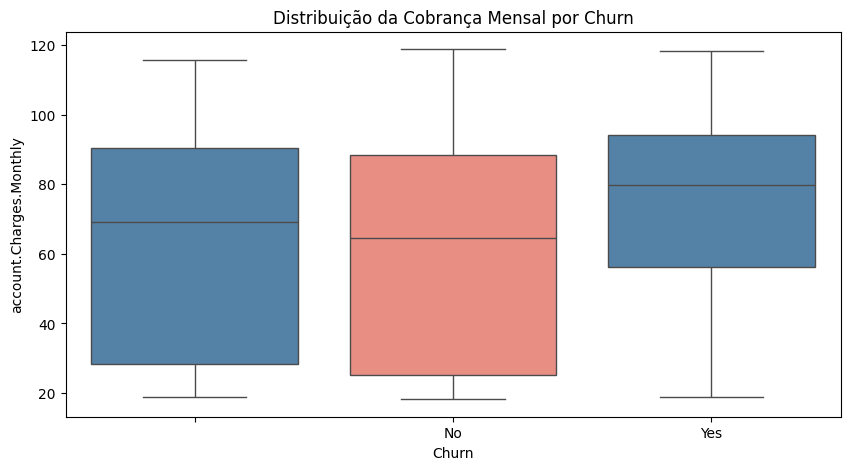

In [46]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,
            x='Churn',
            y='account.Charges.Monthly',
            palette=['steelblue', 'salmon'])
plt.title('Distribuição da Cobrança Mensal por Churn')
plt.show()

Relatório Final - Análise de Evasão de Clientes

Introdução
A análise teve como objetivo identificar padrões relacionados à evasão de clientes da Telecom X. O foco foi entender quais fatores aumentam o risco de churn e como esses insights podem ajudar a empresa a reduzir cancelamentos.

Limpeza e Tratamento de Dados
Durante o processo de preparação dos dados, foram realizadas etapas como:
- padronização dos nomes das colunas;
- tradução de valores (ex.: yes/no → sim/nao);
- remoção de nulos e inconsistências;
- conversão de tipos;
- criação de novas variáveis, como a cobrança diária;
- padronização de texto para minúsculas.
Essas etapas garantiram que as análises e visualizações fossem confiáveis.

Análise Exploratória de Dados
As visualizações mostraram padrões claros:
- Taxa geral de evasão: aproximadamente 26,5%, enquanto 73,5% permanecem na base.
- Tempo de contrato: clientes com menor tempo de contrato têm maior propensão ao churn, indicando que o cancelamento ocorre principalmente nos primeiros meses.
- Gênero: evasão equilibrada entre homens (26,16%) e mulheres (26,92%), mostrando que gênero não é determinante.
- Tipo de contrato: contratos mensais apresentam taxa de evasão significativamente maior do que contratos anuais ou bienais, indicando baixa fidelização.
- Cobrança mensal: clientes que cancelaram tendem a ter cobranças mensais mais altas, sugerindo sensibilidade ao preço.
- Serviço de internet: clientes com internet fibra concentram maior evasão, possivelmente por percepção de custo-benefício ou qualidade.

Conclusões e Insights
A evasão está fortemente relacionada a três fatores principais:
- baixa fidelização (contratos mensais);
- pouco tempo de relacionamento;
- maior custo mensal.
Além disso, fatores demográficos simples, como gênero, não influenciam significativamente o churn. Isso mostra que a evasão está mais ligada a aspectos contratuais e financeiros do que a características pessoais.

Recomendações
Com base nos achados, algumas ações podem ajudar a reduzir o churn:
- Reduzir churn inicial: fortalecer o onboarding e o acompanhamento nos primeiros meses.
- Incentivar contratos mais longos: oferecer benefícios para migração de planos mensais para anuais ou bienais.
- Revisar preços: ajustar planos com cobrança mensal elevada ou oferecer alternativas mais competitivas.
- Investigar serviços com maior evasão: especialmente internet fibra.
- Criar segmentação de risco: identificar clientes com maior probabilidade de evasão e agir preventivamente.
